In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

async def plot_3d_function_slice(func, min_vals, max_vals, epsilon_vals, 
                          input_dims=(0, 1), output_dim=0, 
                          constant_vals=None, resolution=50, 
                          plot_type='surface', title=None):
    """
    Create a 3D visualization of a multidimensional function by plotting 
    two selected input dimensions vs one output dimension.
    
    Parameters:
    -----------
    func : callable
        Function f: R^k1 -> R^k2 that accepts numpy array of length k1
        and returns array of length k2
    min_vals : array-like, shape (k1,)
        Minimum values for each input dimension
    max_vals : array-like, shape (k1,)
        Maximum values for each input dimension  
    epsilon_vals : array-like, shape (k1,)
        Step sizes for each input dimension
    input_dims : tuple of 2 ints, default (0, 1)
        Indices of input dimensions to plot (x-axis, y-axis)
    output_dim : int, default 0
        Index of output dimension to plot (z-axis)
    constant_vals : array-like, shape (k1,), optional
        Constant values for non-plotted dimensions. If None, uses midpoint
    resolution : int, default 50
        Number of points along each axis for the mesh grid
    plot_type : str, default 'surface'
        Type of 3D plot: 'surface', 'wireframe', or 'contour'
    title : str, optional
        Plot title
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    ax : matplotlib.axes._subplots.Axes3DSubplot
        The 3D axes object
    """
    
    # Convert inputs to numpy arrays
    min_vals = np.array(min_vals)
    max_vals = np.array(max_vals)
    epsilon_vals = np.array(epsilon_vals)
    
    k1 = len(min_vals)
    
    # Validate input dimensions
    if len(input_dims) != 2:
        raise ValueError("input_dims must contain exactly 2 dimension indices")
    if max(input_dims) >= k1 or min(input_dims) < 0:
        raise ValueError("input_dims indices must be within valid range")
    
    # Set constant values for non-plotted dimensions
    if constant_vals is None:
        constant_vals = (min_vals + max_vals) / 2  # Use midpoint as default
    else:
        constant_vals = np.array(constant_vals)
        if len(constant_vals) != k1:
            raise ValueError("constant_vals must have length k1")
    
    # Create base parameter vector with constant values
    base_params = constant_vals.copy()
    
    # Get the two input dimensions to vary
    dim1, dim2 = input_dims
    
    # Create coordinate arrays for the two varying dimensions
    x1_range = np.linspace(min_vals[dim1], max_vals[dim1], resolution)
    x2_range = np.linspace(min_vals[dim2], max_vals[dim2], resolution)
    
    # Create meshgrid for surface plotting
    X1, X2 = np.meshgrid(x1_range, x2_range)
    
    # Initialize output array
    Z = np.zeros_like(X1)
    
    # Evaluate function at each point in the grid
    for i in range(resolution):
        for j in range(resolution):
            # Set the varying dimensions in the parameter vector
            params = base_params.copy()
            params[dim1] = X1[i, j]
            params[dim2] = X2[i, j]
            
            # Evaluate function and extract desired output dimension
            result = await func(params)
            Z[i, j] = result[output_dim]
    
    # Create the 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    if plot_type == 'surface':
        surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
        fig.colorbar(surf, shrink=0.5, aspect=8)
    elif plot_type == 'wireframe':
        ax.plot_wireframe(X1, X2, Z, alpha=0.7)
    elif plot_type == 'contour':
        # For contour plots, we'll create a filled contour on a 2D projection
        ax.contour3D(X1, X2, Z, levels=20, cmap='viridis')
    else:
        raise ValueError("plot_type must be 'surface', 'wireframe', or 'contour'")
    
    # Set labels and title
    ax.set_xlabel(f'Input Dimension {dim1}')
    ax.set_ylabel(f'Input Dimension {dim2}')
    ax.set_zlabel(f'Output Dimension {output_dim}')
    
    if title is None:
        title = (f'3D Function Visualization\n'
                f'Input dims: {dim1}, {dim2} | Output dim: {output_dim}')
    ax.set_title(title)
    
    # Add text showing constant values for other dimensions
    other_dims = [i for i in range(k1) if i not in input_dims]
    if other_dims:
        const_text = "Constants: " + ", ".join([
            f"dim{i}={constant_vals[i]:.3f}" for i in other_dims[:5]
        ])
        if len(other_dims) > 5:
            const_text += f" ... (+{len(other_dims)-5} more)"
        plt.figtext(0.02, 0.02, const_text, fontsize=8)
    
    plt.tight_layout()
    return fig, ax


async def plot_interactive_slices(func, min_vals, max_vals, epsilon_vals, 
                           input_dims=(0, 1), output_dim=0, 
                           num_slices=4, plot_type='surface'):
    """
    Create multiple 3D plots with different constant values to explore
    the function behavior across different slices.
    
    Parameters are similar to plot_3d_function_slice, with additional:
    num_slices : int, default 4
        Number of different constant value combinations to try
    """
    
    k1 = len(min_vals)
    other_dims = [i for i in range(k1) if i not in input_dims]
    
    # Create figure with subplots
    fig = plt.figure(figsize=(15, 10))
    
    for slice_idx in range(num_slices):
        # Generate different constant values for each slice
        constant_vals = np.zeros(k1)
        for dim in other_dims:
            # Vary constants across the range for different slices
            t = slice_idx / max(1, num_slices - 1)  # t ranges from 0 to 1
            constant_vals[dim] = min_vals[dim] + t * (max_vals[dim] - min_vals[dim])
        
        # Set the input dimensions to their midpoints (will be overridden in plotting)
        for dim in input_dims:
            constant_vals[dim] = (min_vals[dim] + max_vals[dim]) / 2
        
        ax = fig.add_subplot(2, 2, slice_idx + 1, projection='3d')
        
        # Use a simplified version of the main plotting logic
        dim1, dim2 = input_dims
        resolution = 30  # Lower resolution for multiple plots
        
        x1_range = np.linspace(min_vals[dim1], max_vals[dim1], resolution)
        x2_range = np.linspace(min_vals[dim2], max_vals[dim2], resolution)
        X1, X2 = np.meshgrid(x1_range, x2_range)
        Z = np.zeros_like(X1)
        
        for i in range(resolution):
            for j in range(resolution):
                params = constant_vals.copy()
                params[dim1] = X1[i, j]
                params[dim2] = X2[i, j]
                result = await func(params)
                Z[i, j] = result[output_dim]
        
        if plot_type == 'surface':
            surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
        else:
            ax.plot_wireframe(X1, X2, Z, alpha=0.7)
        
        ax.set_xlabel(f'Dim {dim1}')
        ax.set_ylabel(f'Dim {dim2}')
        ax.set_zlabel(f'Out {output_dim}')
        ax.set_title(f'Slice {slice_idx + 1}')
    
    plt.tight_layout()
    return fig

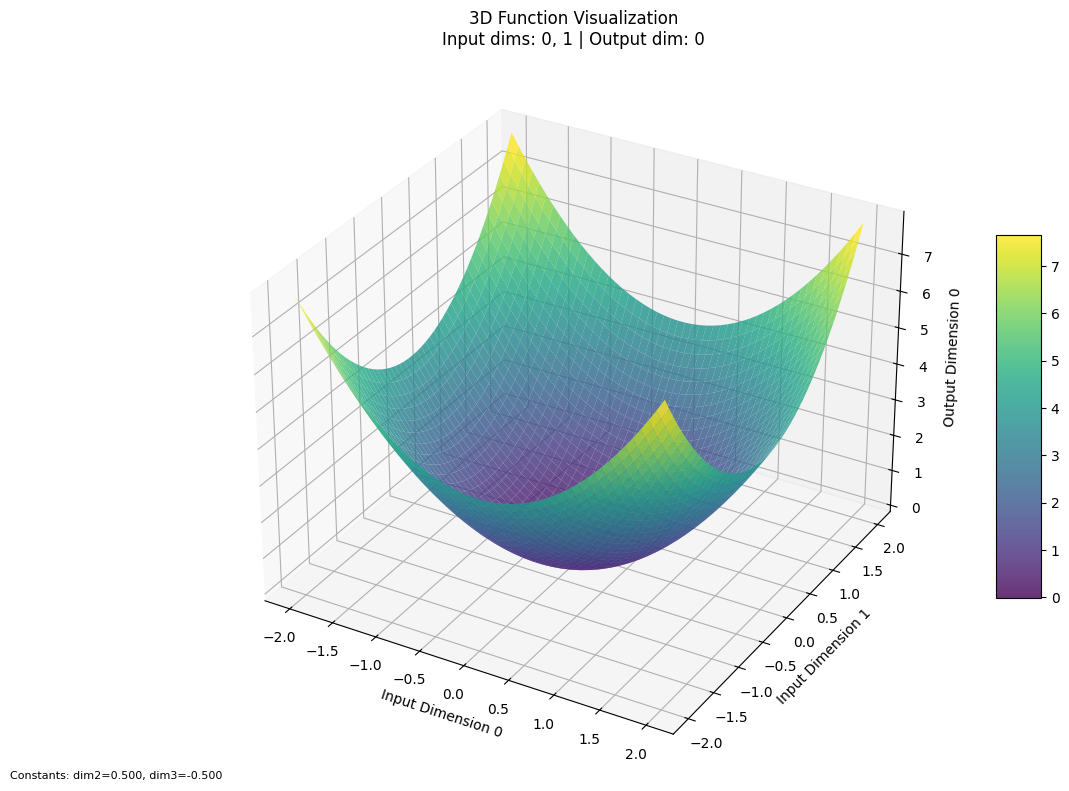

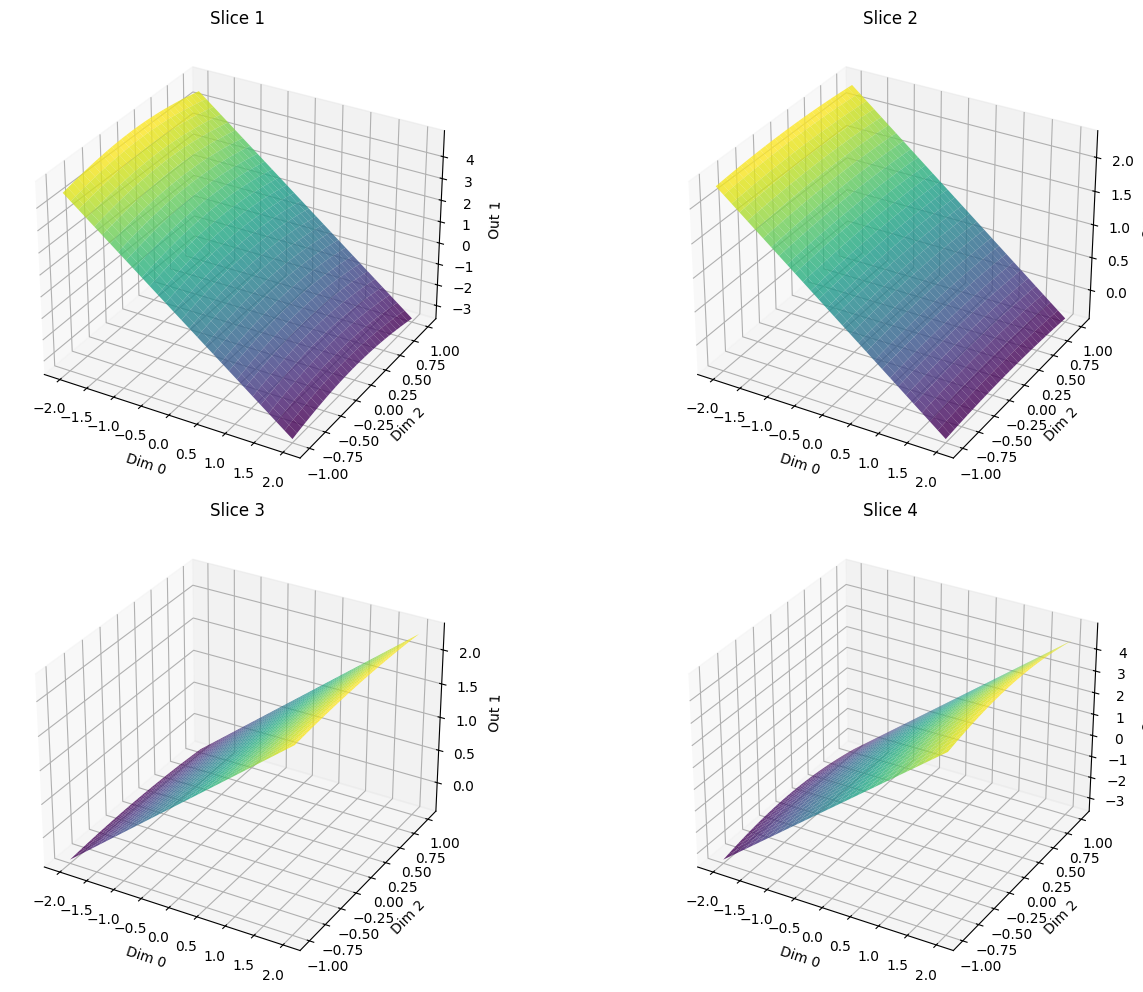

In [5]:
# Example usage and test function
def create_test_function():
    """Create a test function for demonstration"""
    async def test_func(x):
        # Example: f(x1, x2, x3, x4) -> [y1, y2]
        # where y1 = x1^2 + x2^2 + sin(x3) + x4
        #       y2 = x1*x2 + cos(x3*x4)
        x = np.array(x)
        y1 = x[0]**2 + x[1]**2 + np.sin(x[2]) + x[3]
        y2 = x[0]*x[1] + np.cos(x[2]*x[3])
        return np.array([y1, y2])
    
    return test_func

# Demonstration
if __name__ == "__main__":
    # Create test function and parameters
    func = create_test_function()
    min_vals = np.array([-2, -2, -1, -1])
    max_vals = np.array([2, 2, 1, 1]) 
    epsilon_vals = np.array([0.1, 0.1, 0.05, 0.05])
    
    # Example 1: Basic 3D surface plot
    fig1, ax1 = await plot_3d_function_slice(
        func, min_vals, max_vals, epsilon_vals,
        input_dims=(0, 1), output_dim=0,
        constant_vals=np.array([0, 0, 0.5, -0.5]),
        plot_type='surface'
    )
    plt.show()
    
    # Example 2: Multiple slices to explore behavior
    fig2 = await plot_interactive_slices(
        func, min_vals, max_vals, epsilon_vals,
        input_dims=(0, 2), output_dim=1,
        num_slices=4
    )
    plt.show()